Requested backend: cpu
JAX_PLATFORMS: cpu
Active JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
[jaxpy.nquad] default quadrature: logspace_segmentation, seg=8, n=20, log_L=3.0
[jam_axi_proj_jax] using logspace_segmentation, seg = 8


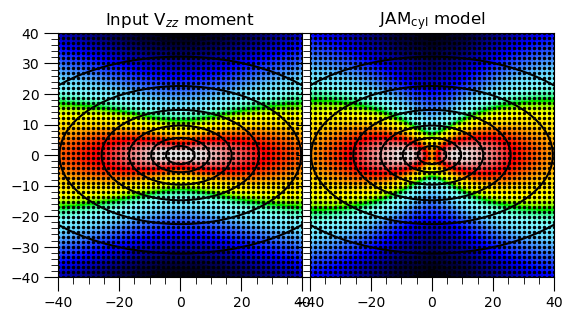

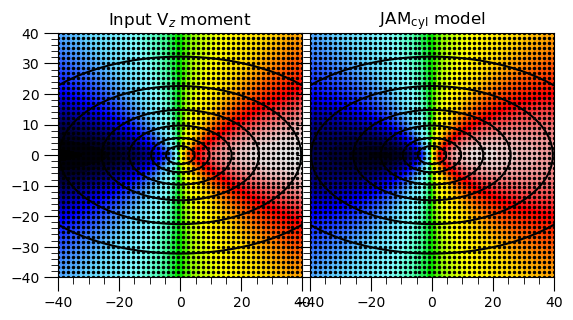

In [1]:
# IMPORTANT: Restart kernel before running this cell, so backend selection is fresh.
import os
import sys
from pathlib import Path

# Resolve local jaxpy path directly.
local_jaxpy_root = str(Path('/mnt/d/lensing/jaxpy/jaxpy/jaxpy'))
sys.path.insert(0, local_jaxpy_root)

# Backend switch (default to CPU before running):
requested_label = "cpu"
GPU = False

# Use explicit CUDA selection to avoid ROCm probing errors in mixed environments.
# Note: changing backend requires restarting the kernel before re-running this cell.
os.environ["JAX_PLATFORMS"] = "cuda,cpu" if GPU else "cpu"

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpyro

try:
    active_backend = jax.default_backend()
    active_devices = jax.devices()
except Exception as exc:
    print(f"[backend] initialization failed: {exc}")
    print("[backend] Try backend='cpu', or verify CUDA-enabled jaxlib in this environment.")
    raise

numpyro.set_platform("gpu" if active_backend == "cuda" else "cpu")

print(f"Requested backend: {requested_label}")
print("JAX_PLATFORMS:", os.environ.get("JAX_PLATFORMS"))
print("Active JAX backend:", active_backend)
print("JAX devices:", active_devices)
if GPU and active_backend != "cuda":
    print("Warning: GPU requested but CUDA backend is not active; running on", active_backend)

from jax.tree_util import Partial as partial
import time
import matplotlib.pyplot as plt
from jax.scipy import special, signal, ndimage
from time import perf_counter as clock
from plotbin.plot_velfield import plot_velfield
from plotbin.symmetrize_velfield import symmetrize_velfield
from jam_axi_intr import mom_interp
import nquad as nq
import numpy as np

from jam_axi_proj_jax import jam_axi_proj

# Uniform sampling grid for stable pcolormesh comparison
nx_grid, ny_grid = 50, 50
x_lin = np.linspace(-40, 40, nx_grid)
y_lin = np.linspace(-40, 40, ny_grid)
x_mesh, y_mesh = np.meshgrid(x_lin, y_lin, indexing='xy')
xbin = x_mesh.ravel()
ybin = y_mesh.ravel()

inc = 60.                                                # Assumed galaxy inclination
r = jnp.sqrt(xbin**2 + (ybin/jnp.cos(jnp.radians(inc)))**2) # Radius in the plane of the disk
a = 40                                                   # Scale length in arcsec
vr = 2000*jnp.sqrt(r)/(r + a)                             # Assumed velocity profile (v_c of Hernquist 1990)
vel = vr * jnp.sin(jnp.radians(inc))*xbin/r                # Projected velocity field
sig = 8700/(r + a)                                       # Assumed velocity dispersion profile
rms = jnp.sqrt(vel**2 + sig**2)                           # Vrms field in km/s

surf = jnp.array([39483., 37158., 30646., 17759., 5955.1, 1203.5, 174.36, 21.105, 2.3599, 0.25493])
sigma = jnp.array([0.153, 0.515, 1.58, 4.22, 10, 22.4, 48.8, 105, 227, 525])
qobs = jnp.full_like(sigma, 0.57)

distance = 16.5     # Assume Virgo distance in Mpc (Mei et al. 2007)
mbh = 1e8           # Black hole mass in solar masses
beta = jnp.full_like(surf, 0.2)
# beta = jnp.array([1.0,0.2,0.2,1.0])

surf_lum = surf_pot = surf
sigma_lum = sigma_pot = sigma
qobs_lum = qobs_pot = qobs

sigmapsf =  jnp.array([0.6, 1.2])
normpsf = jnp.array([0.7, 0.3])
pixsize = 0.8
goodbins = jnp.ones_like(r, dtype=bool)  # keep all bins

# I use a loop below, just to highlight the fact that all parameters
# remain the same for the two JAM calls, except for 'moment' and 'data'

from functools import partial
jam_obj = jam_axi_proj()

for moment, data in zip(['zz', 'z'], [rms, vel]):

        _ = jam_obj.get_kinematics(surf_lum = surf_lum, sigma_lum=sigma_lum, qobs_lum=qobs_lum, surf_pot=surf_pot, sigma_pot=sigma_pot, qobs_pot=qobs_pot,
                            inc=inc, mbh=mbh, distance=distance, xbin=xbin, ybin=ybin, data=data,
                            sigmapsf=sigmapsf, normpsf=normpsf, beta=beta, pixsize=pixsize,logistic = False,
                            moment=moment, goodbins=goodbins, align='cyl', ml=None,quiet=True)

        # The model is by design similar but not identical to the adopted kinematics!
        model, chi2, flux, ml, vel, vel2 = _

        jam_obj.plot(goodbins,moment,model,xbin,ybin,data,'cyl',flux, nodots=False)
        plt.show()

from numpyro.infer import MCMC, NUTS
from numpyro import distributions as dist
import numpyro

surf_lum = jnp.array(surf_lum)
jam_eval = partial(jam_obj.get_kinematics, sigma_lum=sigma_lum, qobs_lum=qobs_lum, 
                   surf_pot=surf_pot, sigma_pot=sigma_pot, qobs_pot=qobs_pot,
                    inc=inc, mbh=mbh, distance=distance, xbin=xbin, ybin=ybin, data=data,
                    sigmapsf=sigmapsf, normpsf=normpsf, beta=beta, pixsize=pixsize,logistic=False,step = 0.05,
                    moment=moment, goodbins=goodbins, align='cyl', ml=None,quiet=True)

In [2]:
# Block: derive nx/ny/nk/step from native jampy grid logic, then inject into JAX JAM
import numpy as np

nrad_use = int(globals().get('nrad', 20))
nang_use = int(globals().get('nang', 10))


def derive_base_grid_params(x, y, sigma_lum, qobs_lum, sigma_psf, pix_size,
                            nrad=20, nang=10, interp=True, step_input=0.0):
    # Match native jampy interpolation/PSF grid-size logic.
    x = np.asarray(x)
    y = np.asarray(y)
    sigma_lum = np.asarray(sigma_lum)
    qobs_lum = np.asarray(qobs_lum)
    sigma_psf = np.asarray(sigma_psf)

    w = sigma_lum < np.max(np.abs(x))
    qmed = np.median(qobs_lum) if w.sum() < 3 else np.median(qobs_lum[w])
    rell = np.hypot(x, y / qmed)

    psf_convolution = (np.max(sigma_psf) > 0) and (pix_size > 0)

    if (not interp) or ((nrad * nang > x.size) and (not psf_convolution)):
        step = np.min(rell) if step_input == 0 else step_input
        mx = 0.0
    else:
        if psf_convolution:
            step = np.min(sigma_psf) / 4 if step_input == 0 else step_input
            mx = 3 * np.max(sigma_psf) + pix_size / np.sqrt(2)
        else:
            step = np.min(rell) if step_input == 0 else step_input
            mx = 0.0

    rmax = np.max(rell) + mx
    nx = int(np.ceil(rmax / step))
    ny = int(np.ceil(rmax * qmed / step))
    nk = int(np.ceil(mx / step))
    return nx, ny, nk, float(step), float(qmed), float(rmax), float(mx)


nx_base, ny_base, nk_base, step_base, qmed_base, rmax_base, mx_base = derive_base_grid_params(
    x=xbin,
    y=ybin,
    sigma_lum=sigma_lum,
    qobs_lum=qobs_lum,
    sigma_psf=sigmapsf,
    pix_size=pixsize,
    nrad=nrad_use,
    nang=nang_use,
    interp=True,
    step_input=0.0,
)

print(f'[derived-base-grid] nx={nx_base}, ny={ny_base}, nk={nk_base}, step={step_base:.6g}')
print(f'[derived-base-grid] qmed={qmed_base:.6g}, rmax={rmax_base:.6g}, mx={mx_base:.6g}')

# One explicit JAX JAM call using the derived grid settings
model_basegrid, chi2_basegrid, flux_basegrid, ml_basegrid, vel_basegrid, vel2_basegrid = jam_obj.get_kinematics(
    surf_lum=surf_lum,
    sigma_lum=sigma_lum,
    qobs_lum=qobs_lum,
    surf_pot=surf_pot,
    sigma_pot=sigma_pot,
    qobs_pot=qobs_pot,
    inc=inc,
    mbh=mbh,
    distance=distance,
    xbin=xbin,
    ybin=ybin,
    data=rms,
    sigmapsf=sigmapsf,
    normpsf=normpsf,
    beta=beta,
    pixsize=pixsize,
    logistic=False,
    moment='zz',
    goodbins=goodbins,
    align='cyl',
    ml=None,
    nx=nx_base,
    ny=ny_base,
    nk=nk_base,
    step=step_base,
    quiet=True,
)

print(f'[jax-with-derived-grid] chi2={float(np.asarray(chi2_basegrid)):.6f}, ml={float(np.asarray(ml_basegrid)):.6f}, mean(model)={float(np.asarray(model_basegrid).mean()):.6g}')



[derived-base-grid] nx=567, ny=323, nk=28, step=0.15
[derived-base-grid] qmed=0.57, rmax=84.9406, mx=4.16569
[jax-with-derived-grid] chi2=1.097874, ml=1.186672, mean(model)=125.956


In [ ]:
# Block: base-vs-jax four-panel comparison (native jampy vs jax jampy)
import os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

local_jampy_root = '/mnt/d/lensing/Jampy/jampy-8.1.4'
sys.path.insert(0, local_jampy_root)
print(f'using local jampy source: {local_jampy_root}')


import jampy
import jampy.axi.jam_axi_proj as jam_base_mod
jam_base_mod = importlib.reload(jam_base_mod)
from jampy.axi.jam_axi_proj import jam_axi_proj as jam_base

print(f'base jampy version: {jampy.__version__}')
print(f'grid injected to jax: nx={nx_base}, ny={ny_base}, nk={nk_base}, step={step_base:.6g}')
print('nrad = number of logarithmic radial points on polar interpolation grid')
print('nang = number of linear eccentric-anomaly points on polar interpolation grid')
print('[note] native base jampy does not take nx/ny/nk kwargs; jax call below uses injected nx/ny/nk.')

common_kwargs = dict(
    surf_lum=surf_lum,
    sigma_lum=sigma_lum,
    qobs_lum=qobs_lum,
    surf_pot=surf_pot,
    sigma_pot=sigma_pot,
    qobs_pot=qobs_pot,
    inc=inc,
    mbh=mbh,
    distance=distance,
    xbin=xbin,
    ybin=ybin,
    data=rms,
    sigmapsf=sigmapsf,
    normpsf=normpsf,
    beta=beta,
    pixsize=pixsize,
    logistic=False,
    moment='zz',
    goodbins=goodbins,
    align='cyl',
    ml=None,
    nrad=20,
    nang=10,
    nlos=1500,
    step=step_base,
)

# Base jampy expects numpy/scalar types.
scalar_keys = {'inc', 'mbh', 'distance', 'pixsize', 'step'}
pass_keys = {'logistic', 'moment', 'align', 'ml'}
base_kwargs = {}
for k, v in common_kwargs.items():
    if k in scalar_keys:
        base_kwargs[k] = float(v)
    elif k in pass_keys:
        base_kwargs[k] = v
    elif k == 'goodbins':
        base_kwargs[k] = np.asarray(v, dtype=bool)
    else:
        base_kwargs[k] = np.asarray(v)

jam_b_cmp = jam_base(**base_kwargs, plot=False, quiet=True)
model_base_cmp = np.asarray(jam_b_cmp.model)

# JAX call reuses the same common kwargs + injected grid controls.
jax_kwargs = dict(common_kwargs, nx=nx_base, ny=ny_base, nk=nk_base)
model_jax_cmp, chi2_jax_cmp, flux_jax_cmp, ml_jax_cmp, vel_jax_cmp, vel2_jax_cmp = jam_obj.get_kinematics(
    **jax_kwargs,
    quiet=True,
)
model_jax_cmp = np.asarray(model_jax_cmp)

eps = np.finfo(float).eps
pct_diff_cmp = 100.0 * (model_jax_cmp - model_base_cmp) / np.where(np.abs(model_base_cmp) > eps, np.abs(model_base_cmp), np.nan)
abs_diff_cmp = np.abs(model_jax_cmp - model_base_cmp)

vmin = np.nanmin([np.nanmin(model_base_cmp), np.nanmin(model_jax_cmp)])
vmax = np.nanmax([np.nanmax(model_base_cmp), np.nanmax(model_jax_cmp)])

x_arr = np.asarray(xbin)
y_arr = np.asarray(ybin)
x_unique = np.unique(x_arr)
y_unique = np.unique(y_arr)


def to_grid(values):
    values = np.asarray(values)
    grid = np.full((y_unique.size, x_unique.size), np.nan)
    ix = np.searchsorted(x_unique, x_arr)
    iy = np.searchsorted(y_unique, y_arr)
    grid[iy, ix] = values
    return grid

base_grid = to_grid(model_base_cmp)
jax_grid = to_grid(model_jax_cmp)
diff_grid = to_grid(pct_diff_cmp)
abs_grid = to_grid(abs_diff_cmp)

dmax = np.nanmax(np.abs(diff_grid))
admax = np.nanmax(abs_grid)


def add_top_cbar(fig, mappable, ax, title, label):
    try:
        cbar = fig.colorbar(mappable, ax=ax, location='top', fraction=0.03, pad=0.05, format='%.3g')
    except TypeError:
        cbar = fig.colorbar(mappable, ax=ax, orientation='horizontal', fraction=0.03, pad=0.12, format='%.3g')
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.set_ticks_position('bottom')
    cbar.ax.xaxis.get_offset_text().set_visible(False)
    cbar.ax.tick_params(labelsize=8, pad=2)
    cbar.set_label(f'{title} | {label}', fontsize=9, labelpad=8)
    return cbar


# Compact layout: near-zero outer whitespace + square pcolormesh panels
xmin, xmax = float(np.min(x_unique)), float(np.max(x_unique))
ymin, ymax = float(np.min(y_unique)), float(np.max(y_unique))
span = max(xmax - xmin, ymax - ymin)
xc, yc = 0.5 * (xmin + xmax), 0.5 * (ymin + ymax)
xlim_sq = (xc - 0.5 * span, xc + 0.5 * span)
ylim_sq = (yc - 0.5 * span, yc + 0.5 * span)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=False)
fig.subplots_adjust(left=0.004, right=0.996, bottom=0.015, top=0.84, wspace=0.008)

pc0 = axes[0].pcolormesh(x_unique, y_unique, base_grid, shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
axes[0].set_xlabel('x [arcsec]')
axes[0].set_ylabel('y [arcsec]')
add_top_cbar(fig, pc0, axes[0], 'Base jampy Vrms model', 'Vrms [km/s]')

pc1 = axes[1].pcolormesh(x_unique, y_unique, jax_grid, shading='auto', cmap='jet', vmin=vmin, vmax=vmax)
axes[1].set_xlabel('x [arcsec]')
axes[1].set_ylabel('')
axes[1].tick_params(labelleft=False)
add_top_cbar(fig, pc1, axes[1], 'JAX jampy Vrms model', 'Vrms [km/s]')

norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax) if dmax > 0 else None
pc2 = axes[2].pcolormesh(x_unique, y_unique, np.nan_to_num(diff_grid, nan=0.0), shading='auto', cmap='coolwarm', norm=norm)
axes[2].set_xlabel('x [arcsec]')
axes[2].set_ylabel('')
axes[2].tick_params(labelleft=False)
add_top_cbar(fig, pc2, axes[2], 'Vrms difference (%) (JAX - Base)', '%')

for ax in axes:
    ax.set_xlim(*xlim_sq)
    ax.set_ylim(*ylim_sq)
    ax.set_aspect('equal', adjustable='box')
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='both', labelsize=8, pad=1)
    ax.scatter(x_arr, y_arr, s=4, c='k', alpha=0.15, linewidths=0, zorder=3)

out_png = 'jax_vs_base_comparison.png'
fig.savefig(out_png, dpi=240, bbox_inches='tight', pad_inches=0.01)
print(f'saved figure: {out_png}')
plt.show()

finite_pct = pct_diff_cmp[np.isfinite(pct_diff_cmp)]
print(f'chi2 (jax/base): {float(np.asarray(chi2_jax_cmp)):.6f} / {float(jam_b_cmp.chi2):.6f}')
print(f'ml   (jax/base): {float(np.asarray(ml_jax_cmp)):.6f} / {float(jam_b_cmp.ml):.6f}')
print(f'|ΔVrms| stats [km/s]: mean={abs_diff_cmp.mean():.6g}, median={np.median(abs_diff_cmp):.6g}, max={abs_diff_cmp.max():.6g}')
if finite_pct.size:
    print(f'Δ% stats: mean={finite_pct.mean():.6g}%, median={np.median(finite_pct):.6g}%, max|%|={np.max(np.abs(finite_pct)):.6g}%')
else:
    print('Δ% stats: all invalid (base model contains zeros everywhere).')



# Max-bias diagnostics
idx_max_abs = int(np.argmax(abs_diff_cmp))
print(
    f'max |ΔVrms| at (x,y)=({float(np.asarray(xbin)[idx_max_abs]):.4g}, {float(np.asarray(ybin)[idx_max_abs]):.4g}) arcsec: '
    f'{float(abs_diff_cmp[idx_max_abs]):.6g} km/s '
    f'(base={float(model_base_cmp[idx_max_abs]):.6g}, jax={float(model_jax_cmp[idx_max_abs]):.6g})'
)

finite_mask = np.isfinite(pct_diff_cmp)
if np.any(finite_mask):
    idx_max_pct = int(np.nanargmax(np.abs(pct_diff_cmp)))
    print(
        f'max |Δ%| at (x,y)=({float(np.asarray(xbin)[idx_max_pct]):.4g}, {float(np.asarray(ybin)[idx_max_pct]):.4g}) arcsec: '
        f'{float(np.abs(pct_diff_cmp[idx_max_pct])):.6g}% '
        f'(signed={float(pct_diff_cmp[idx_max_pct]):.6g}%)'
    )


local Jampy/jampy-8.1.4 not found; using installed jampy package.


[jam_axi_proj_jax] using logspace_segmentation, seg = 8
333.51388235280007


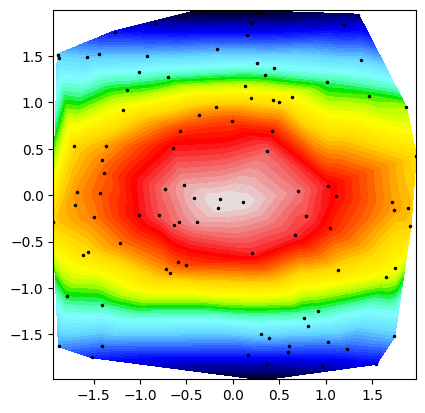

In [ ]:
from SLCOSMO import tool
from MGE_jax import MGE
import pickle as pkl
import param_util
file = 'lens_light_jackpot.pkl'
lens_light = pkl.load(open(file, 'rb'))[0]
surf_lum_jackpot = lens_light['amp']
sigma_lum_jackpot = lens_light['sigma']
phi, qobs_lum_jackpot = param_util.ellipticity2phi_q(lens_light['e1'], lens_light['e2'])
# qobs_lum_jackpot = qobs_lum_jackpot/qobs_lum_jackpot
beta_jackpot = jnp.full_like(surf_lum_jackpot, 0.0)


xbin, ybin = np.random.uniform(low=[-2, -2], high=[2, 2], size=[100, 2]).T
cosmology = {'Omegam': 0.3, 'Omegak': 0.0, 'w0': -1.0, 'wa': 0.0, 'h0': 70.0}
kwargs_epl = {'thetaE': 2, 'gamma': 2, 'zl': 0.2, 'zs': 0.4, 'cosmology':cosmology}
dl, ds, dls = tool.dldsdls(0.2, 0.4, cosmology, n=20)
distance = dl[0]
mge_epl = MGE(tool.EPL_msunmpc, 'thetaE', n_gauss=10, n_terms=28, sigma_start_mult=1/100, sigma_end_mult=50)
mass_amplitude, mass_sigma = mge_epl.decompose(**kwargs_epl)

surf_pot = mass_amplitude
sigma_pot = mass_sigma
qobs_pot = jnp.full_like(mass_amplitude, 0.9)


jam_obj = jam_axi_proj()
_ = jam_obj.get_kinematics(surf_lum = surf_lum_jackpot, sigma_lum=sigma_lum_jackpot, qobs_lum=qobs_lum_jackpot, 
                           surf_pot=surf_pot, sigma_pot=sigma_pot, qobs_pot=qobs_pot,
                    inc=90, mbh=0.0, distance=distance, xbin=xbin, ybin=ybin,step = 0.05,
                    sigmapsf=sigmapsf, normpsf=normpsf, beta=beta_jackpot, pixsize=pixsize,logistic = False,
                    moment='zz', align='cyl', ml=None,quiet=True)
model, chi2, flux, ml, vel, vel2  = _

plot_velfield(xbin, ybin, jnp.clip(model,-1e3,1e3))
print(model.mean())

In [ ]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC, init_to_median

key = jax.random.PRNGKey(42)
err_sigma = 20.0  # km/s per pixel

model_true = model
noise = err_sigma * jax.random.normal(key, shape=model_true.shape)
sigma_obs_full = model_true + noise
sigma_obs = sigma_obs_full
x_obs = xbin
y_obs = ybin

jam_eval = partial(jam_obj.get_kinematics,         
                   surf_lum = surf_lum_jackpot,
                    sigma_lum = sigma_lum_jackpot,
                    qobs_lum = qobs_lum_jackpot,
                    inc = 90.0,
                    mbh = 0.0,
                    distance = distance,
                    xbin = xbin,
                    ybin = ybin,
                    sigmapsf = sigmapsf,
                    normpsf = normpsf,
                    pixsize = pixsize,
                    logistic = False,
                    step = 0.05,
                    moment = 'zz',
                    align = 'cyl',
                    ml = None,
                    quiet = True)

def lens_kinematics_model(sigma_obs):

    # --- Priors ---
    thetaE = numpyro.sample("thetaE", dist.Uniform(1.9, 2.1))      # arcsec-ish
    gamma  = numpyro.sample("gamma",  dist.Uniform(1.6, 2.4))      # EPL slope
    beta   = numpyro.sample("beta",   dist.Uniform(-0.5, 0.8))     # JAM anisotropy
    q      = numpyro.sample("q",      dist.Uniform(0.3, 1))         # EPL axis ratio

    beta_vec = jnp.full_like(surf_lum_jackpot, beta)

    mass_amp, mass_sig = mge_epl.decompose(
        thetaE=thetaE, gamma=gamma,
        zl=kwargs_epl["zl"], zs=kwargs_epl["zs"], cosmology=kwargs_epl["cosmology"]
    )
    qobs_pot_local = jnp.full_like(mass_amp, q)

    pred_model, *_ = jam_eval(
                surf_pot = mass_amp,
                sigma_pot = mass_sig,
                beta = beta_vec,
                qobs_pot = qobs_pot_local
    )

    sigma = err_sigma * jnp.ones_like(pred_model)

    with numpyro.plate("pixels", pred_model.size):
        numpyro.sample("obs", dist.Normal(pred_model, sigma), obs=sigma_obs)

nuts = NUTS(lens_kinematics_model, init_strategy=init_to_median(), target_accept_prob=0.8)

backend_now = jax.default_backend()
if GPU:
    # GPU setting requested: 100 warmup / 100 samples / 8 chains.
    # Note: NumPyro valid chain_method is 'vectorized' (not 'cetorized').
    mcmc = MCMC(
        nuts,
        num_warmup=100,
        num_samples=100,
        num_chains=8,
        progress_bar=True,
        chain_method='vectorized',
    )
    print("[MCMC] GPU backend detected (cuda): warmup=100, samples=100, chains=8, chain_method='vectorized'")
else:
    # Lightweight CPU fallback for quick checks.
    mcmc = MCMC(
        nuts,
        num_warmup=10,
        num_samples=10,
        num_chains=1,
        progress_bar=True,
        chain_method='sequential',
    )
    print(f"[MCMC] non-GPU backend ({backend_now}): warmup=10, samples=10, chains=1, chain_method='sequential'")

rng = jax.random.PRNGKey(0)
mcmc.run(rng, sigma_obs=sigma_obs)


[MCMC] GPU backend detected (cuda): warmup=100, samples=100, chains=8, chain_method='vectorized'


sample: 100%|██████████| 200/200 [07:45<00:00,  2.33s/it]


divergences per chain per step:
 [0 0 0 0 0 0 0 0]


/tmp/ipykernel_370878/2323325282.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


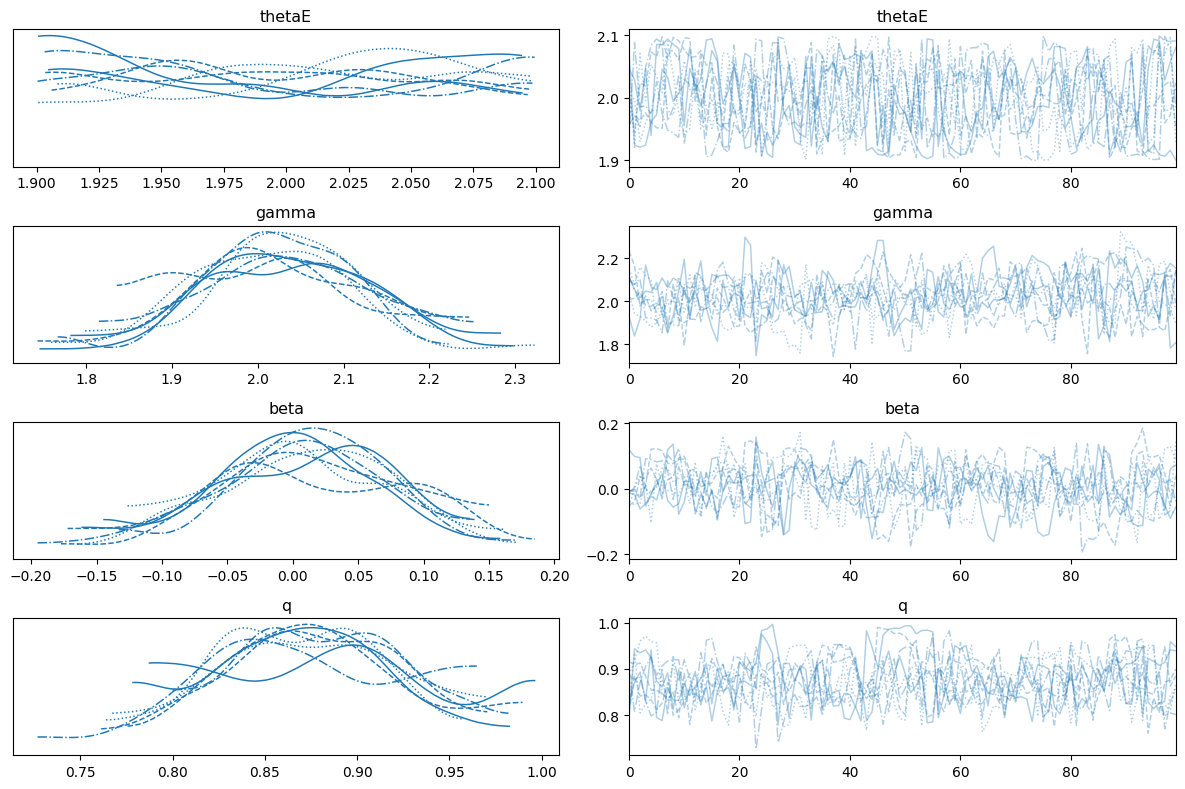

In [ ]:
import arviz as az
import corner as corner
inf_data = az.from_numpyro(mcmc)
print(f'divergences per chain per step:\n {inf_data.sample_stats.diverging.values.sum(axis=1).T}')
plt.rcParams['figure.constrained_layout.use'] = True
_ = az.plot_trace(inf_data, var_names=['thetaE', 'gamma', 'beta', 'q'])
plt.tight_layout()

divergences per chain per step:
 [0 0 0 0]


  fig.subplots_adjust(


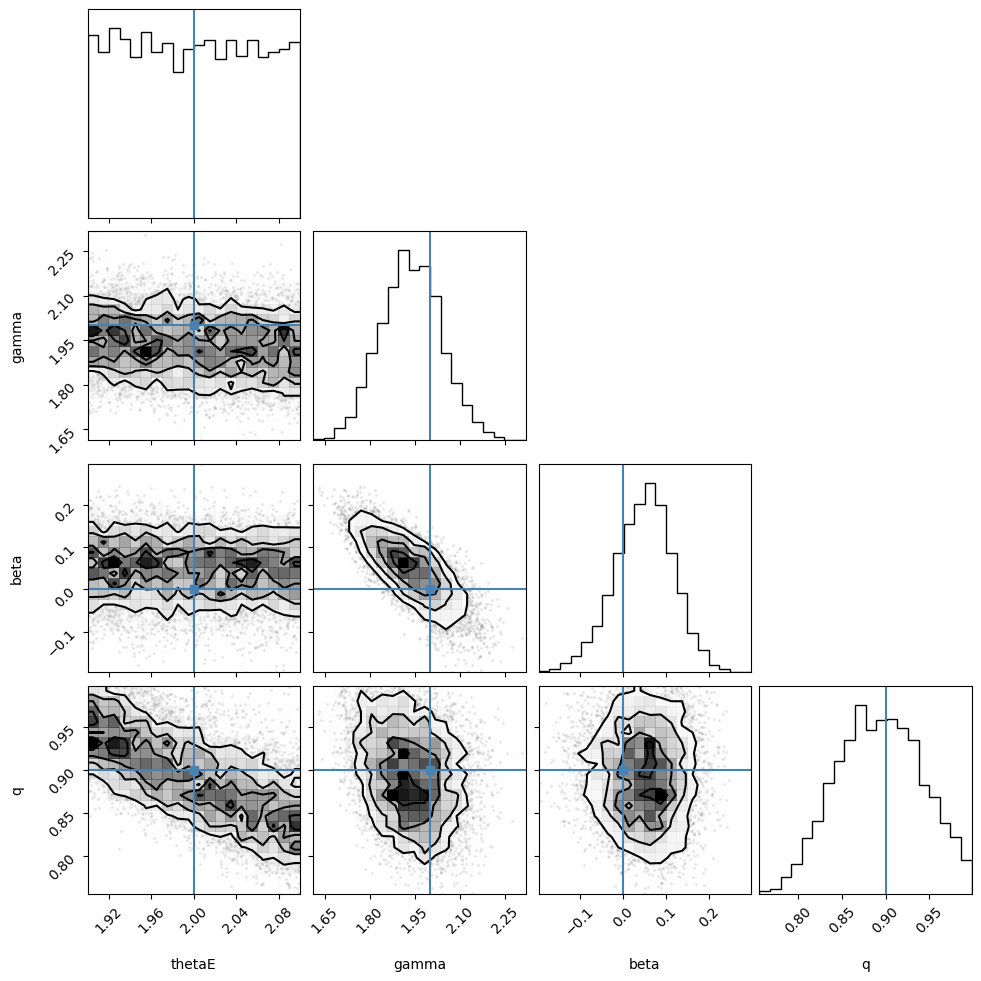

In [ ]:
import arviz as az
import corner as corner
inf_data = az.from_numpyro(mcmc)
print(f'divergences per chain per step:\n {inf_data.sample_stats.diverging.values.sum(axis=1).T}')

varnames = ['thetaE','gamma','beta', 'q']
az.summary(inf_data, var_names=varnames)
corner.corner(inf_data,var_names = varnames, truths = [2, 2, 0, 0.9]);

In [ ]:
median = inf_data.posterior.median(dim=('draw', 'chain'))

mass_amp, mass_sig = mge_epl.decompose(
    thetaE=2, gamma=np.array(median.gamma),
    zl=kwargs_epl["zl"], zs=kwargs_epl["zs"], cosmology=kwargs_epl["cosmology"]
)
qobs_pot_local = jnp.full_like(mass_amp, np.array(median.q))
beta_vec = jnp.full_like(surf_lum_jackpot, np.array(median.beta))

pred_model, *_ = jam_eval(
            surf_pot = mass_amp,
            sigma_pot = mass_sig,
            beta = beta_vec,
            qobs_pot = qobs_pot_local
)


/tmp/ipykernel_744337/202907135.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


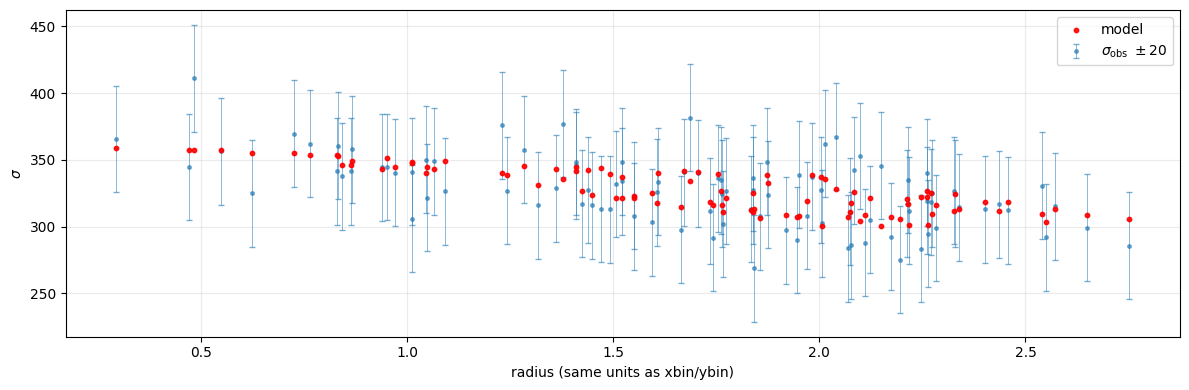

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

r = np.hypot(xbin, ybin).ravel()          
y_obs = sigma_obs.ravel()
y_mod = pred_model.ravel()

plt.figure(figsize=(12,4))
plt.errorbar(r, y_obs, yerr=40.0, fmt='o', ms=2.5, lw=0.8,
             elinewidth=0.6, capsize=2, alpha=0.6,
             label=r'$\sigma_{\rm obs}\ \pm 20$')
plt.scatter(r, y_mod, s=10, alpha=0.9, label='model', zorder=3, c = 'red')

plt.xlabel('radius (same units as xbin/ybin)')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
